## 1. Resumen del Tema de Investigación

* **Título:** *“Determinantes macroeconómicos y financieros del rendimiento bursátil del sector bancario en economías emergentes: Un análisis multifactorial para Credicorp Ltd. (2021-2026)”*.
* **Objetivo:** Evaluar y cuantificar el impacto que tienen las fuerzas del mercado local, el entorno financiero global y las materias primas sobre las variaciones del rendimiento logarítmico de la acción de Credicorp Ltd. ($BAP$). Esto permite entender qué tan vulnerable o resiliente es el holding financiero más grande del Perú ante choques macroeconómicos.

---

## 2. El Modelo Económico (Marco Teórico)

La investigaciòn se fundamenta en la **Teoría de Valoración por Arbitraje (APT)** desarrollada por **Stephen Ross (1976)** y en el modelo **CAPM de Sharpe (1964)**. La teoría APT sostiene que el rendimiento de un activo financiero no solo depende de un mercado general, sino de múltiples factores de riesgo sistemático independientes.

El modelo econométrico final (estimado por Mínimos Cuadrados Ordinarios) se plantea así:

$$R_{Credicorp, t} = \beta_0 + \beta_1 R_{Mercado\_Peru, t} + \beta_2 R_{Cobre, t} + \beta_3 R_{Financiero\_Global, t} + \varepsilon_t$$

---

## 3. Variables

### Variable endogena ($Y$)

* **Rendimiento de Credicorp ($R_{Credicorp}$):** Se utilizan los rendimientos logarítmicos continuos de la acción más líquida del holding financiero.

### Variables exogenas ($X$)

* **$R_{Mercado\_Peru}$ (Rendimiento del Mercado Local / ETF EPU):** 
  - *Justificación:* **Sharpe (1964) y Lintner (1965)** en el desarrollo del *Capital Asset Pricing Model (CAPM)*.
  - *Explicación:* Postulan que el rendimiento de cualquier acción está ligado intrínsecamente a la evolución de su mercado local (Riesgo Sistemático o Beta). Como viste en tus primeros resultados, es el factor con mayor peso y significancia debido a la alta correlación estructural de Credicorp con la economía peruana.


* **$R_{Financiero\_Global}$ (Rendimiento del Sector Financiero Global / ETF XLF):**
  - *Justificación:* **Flannery y James (1984)**, en su estudio pionero sobre la sensibilidad de las acciones bancarias a los factores de riesgo financiero y tasas de interés. Asimismo, los economistas de la **Reserva Federal (2025)** respaldan el uso de enfoques basados en factores sectoriales específicos para aislar el comportamiento de la banca del resto de industrias (como las tecnológicas).
  - *Explicación:* Credicorp no se mueve igual que una empresa industrial; al ser un banco, es altamente sensible al riesgo de contagio financiero internacional, la liquidez global y las políticas de tasas de interés de los bancos centrales.


* **$R_{Cobre}$ (Variación del Precio del Cobre / HG=F):**
  - *Justificación:* **Mendoza (1995)** y localmente investigaciones del **Banco Central de Reserva del Perú (BCRP, 2026)** sobre los efectos de los precios de los *commodities* en la estabilidad macroeconómica interna. También **Beck, Demirgüç-Kunt y Levine (2015)** explican que en economías emergentes dependientes de recursos primarios, los precios de las materias primas determinan la salud crediticia de los bancos.
  - *Explicación:* Al ser el cobre el principal producto de exportación de Perú, un incremento en su precio expande la economía real, reduce los ratios de morosidad de los clientes del banco (BCP, Mibanco) y eleva los márgenes de ganancia de Credicorp, impactando positivamente el precio de su acción.





In [1]:
import requests
import pandas as pd

def descargar_bcrp(codigo, inicio=None, fin=None):

    url = f"https://estadisticas.bcrp.gob.pe/estadisticas/series/api/{codigo}/json"

    if inicio:
        url += f"/{inicio}"

    if fin:
        url += f"/{fin}"

    data = requests.get(url).json()

    df = pd.DataFrame({
        "fecha": [p["name"] for p in data["periods"]],
        "valor": [
            float(p["values"][0]) if p["values"][0] else None
            for p in data["periods"]
        ]
    })

    return df

df_bcrp = descargar_bcrp(
    "PD04722MM",
    inicio="2020-11",
    fin="2025-11"
)


In [2]:
import pandas as pd
import numpy as np
import yfinance as yf

# 1. Definimos un diccionario con el nombre que queremos y su Ticker de Yahoo
TICKERS = {
    'Credicorp': 'BAP',
    'Peru_Mercado': 'EPU',
    'Precio_cobre': 'HG=F',
    'ETF_XLF': 'XLF'
}

START_DATE = "2020-01-01"
END_DATE = "2026-05-31"

df_precios = pd.DataFrame()

print("Descargando datos...")

# Activos con datos mensuales directos
for nombre, ticker in TICKERS.items():
    data = yf.download(
        ticker,
        start=START_DATE,
        end=END_DATE,
        interval="1d",
        auto_adjust=True,
        progress=False
    )

    precio = data['Close'].resample('ME').last()
    precio.index = precio.index.to_period('M')

    df_precios[nombre] = precio

# Limpiar filas donde se crucen días feriados o sin datos
df_precios = df_precios.dropna()

# 3. Transformar los precios a rendimientos logarítmicos
df_rendimientos = np.log(df_precios / df_precios.shift(1)).dropna()

# 4. Renombrar las columnas con el prefijo 'R_' para saber que son rendimientos
df_rendimientos.columns = ['R_Credicorp', 'R_Peru_Mercado', 'Precio_cobre', 'ETF_XLF']

# 5. Guardar el resultado en un CSV
df_rendimientos.to_csv("base_datos_econometria.csv")
df_precios.to_csv("precios_mensuales.csv")
print("\n¡Todo listo! Base de datos guardada como 'base_datos_econometria.csv'")
print(f"Total de registros listos para la regresión: {len(df_rendimientos)}")
print(df_rendimientos.head())

Descargando datos...

¡Todo listo! Base de datos guardada como 'base_datos_econometria.csv'
Total de registros listos para la regresión: 76
         R_Credicorp  R_Peru_Mercado  Precio_cobre   ETF_XLF
Date                                                        
2020-02    -0.130700       -0.097519      0.010265 -0.119328
2020-03    -0.236654       -0.302733     -0.128048 -0.236177
2020-04     0.176326        0.091047      0.049640  0.090408
2020-05    -0.078132        0.076873      0.030334  0.026842
2020-06    -0.030574        0.057214      0.111789 -0.005242


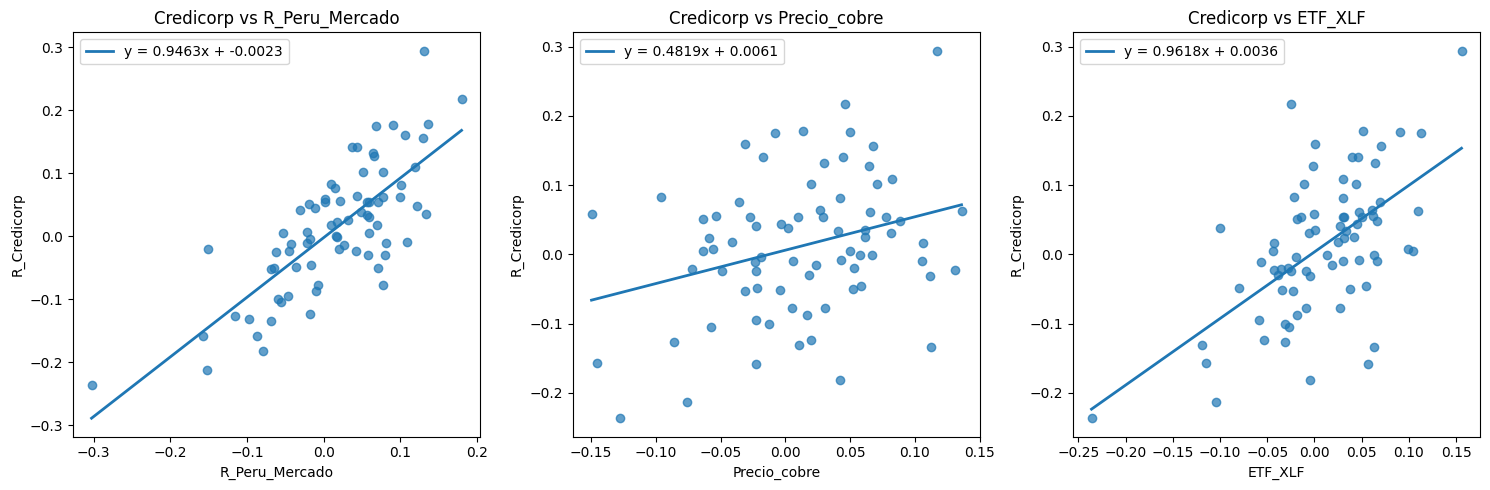

In [3]:
from scipy import stats
import matplotlib.pyplot as plt
import numpy as np

# Variable dependiente
y = df_rendimientos['R_Credicorp']

# Variables independientes
variables = {
    'R_Peru_Mercado': df_rendimientos['R_Peru_Mercado'],
    'Precio_cobre': df_rendimientos['Precio_cobre'],
    'ETF_XLF': df_rendimientos['ETF_XLF']
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (nombre, x) in zip(axes, variables.items()):

    # Gráfico de dispersión
    ax.scatter(x, y, alpha=0.7)

    # Línea de tendencia (regresión lineal)
    coef = np.polyfit(x, y, 1)
    tendencia = np.poly1d(coef)

    # Ordenar para una línea suave
    idx = np.argsort(x)

    ax.plot(
        x.iloc[idx],
        tendencia(x.iloc[idx]),
        linewidth=2,
        label=f'y = {coef[0]:.4f}x + {coef[1]:.4f}'
    )

    ax.set_title(f'Credicorp vs {nombre}')
    ax.set_xlabel(nombre)
    ax.set_ylabel('R_Credicorp')
    ax.legend()

plt.tight_layout()
plt.show()

In [4]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression

x = df_rendimientos['ETF_XLF']
y = df_rendimientos['R_Credicorp']

x_train, x_test, y_train, y_test = train_test_split(x.values.reshape(-1, 1), y.values, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(x_train, y_train)

scores = cross_val_score(model, x_train, y_train, cv=5, scoring='r2')
print(scores)
print(f"R² promedio de validación cruzada: {scores.mean():.4f}")



[ 0.61717735 -0.33510499  0.17303401  0.53344994  0.1635714 ]
R² promedio de validación cruzada: 0.2304


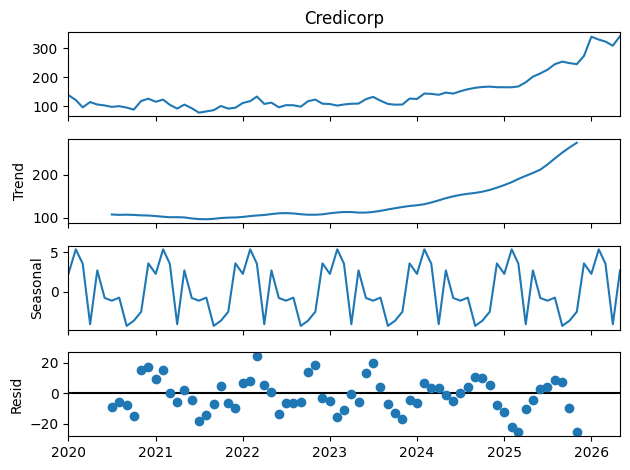

In [5]:
import statsmodels.api as sm
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv('precios_mensuales.csv')
data['Date'] = pd.to_datetime(data['Date'])

data.set_index('Date', inplace=True)
result = sm.tsa.seasonal_decompose(
    data['Credicorp'],
    model='additive',
    period=12
)

result.plot()
plt.show()

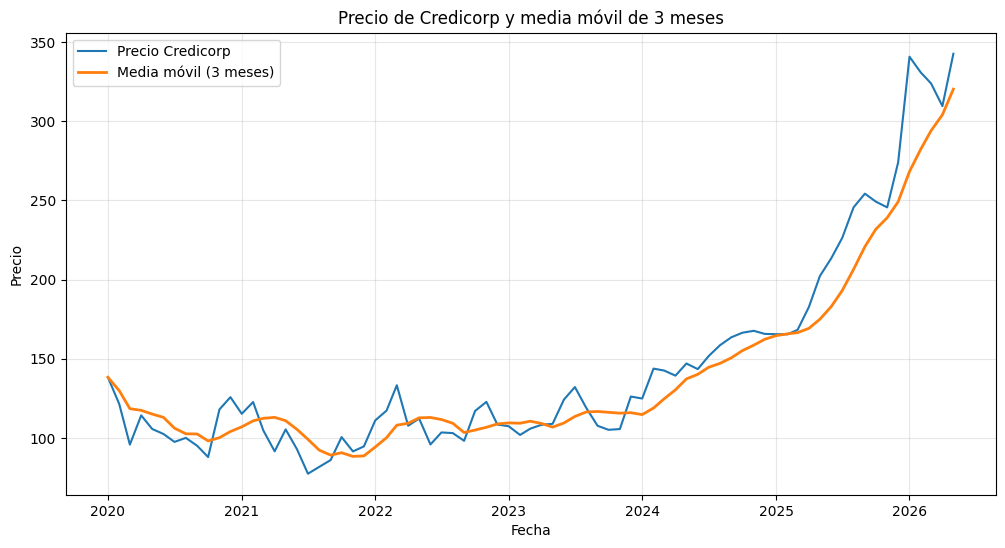

In [6]:
# Medias moviles
import pandas as pd
import matplotlib.pyplot as plt

# Cargar datos
df = pd.read_csv('precios_mensuales.csv', parse_dates=['Date'])

# Establecer fecha como índice
df.set_index('Date', inplace=True)

# Media móvil simple de 3 meses
df['SMA_3'] = df['Credicorp'].rolling(
    window=6,
    min_periods=1
).mean()

# Gráfico
plt.figure(figsize=(12, 6))

plt.plot(
    df.index,
    df['Credicorp'],
    label='Precio Credicorp'
)

plt.plot(
    df.index,
    df['SMA_3'],
    label='Media móvil (3 meses)',
    linewidth=2
)

plt.title('Precio de Credicorp y media móvil de 3 meses')
plt.xlabel('Fecha')
plt.ylabel('Precio')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()


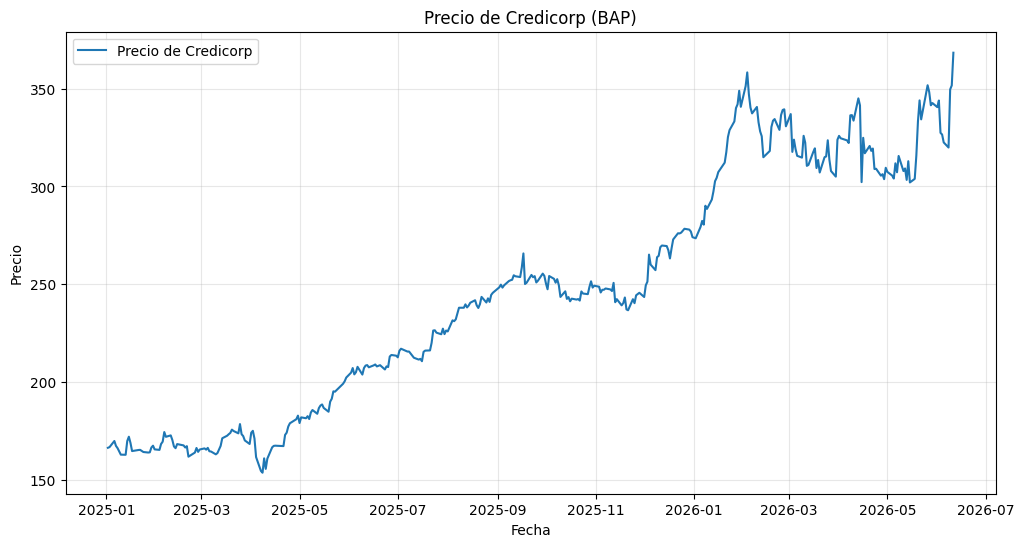

In [7]:
from statsmodels.tsa.arima.model import ARIMA
import yfinance as yf

simbolo = 'BAP'
START_DATE = "2025-01-01"
END_DATE = "2026-06-12"

# interval mensual 
stock = yf.download(
    simbolo,
    start=START_DATE,
    end=END_DATE,
    interval="1d",
    auto_adjust=True,
    progress=False
)

# graficar precios
plt.figure(figsize=(12, 6))
plt.plot(stock['Close'], label='Precio de Credicorp')
plt.title('Precio de Credicorp (BAP)')  
plt.xlabel('Fecha')
plt.ylabel('Precio')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()





In [30]:
p, d, q = 1, 1, 0
model = ARIMA(stock['Close'], order=(p, d, q))
model_fit = model.fit()
forecast = model_fit.forecast(steps=256)
print(f"Predicciones para los próximos 256 días: {forecast}")


/home/prantony/Documents/inv_unidad02/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/prantony/Documents/inv_unidad02/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/prantony/Documents/inv_unidad02/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/prantony/Documents/inv_unidad02/.venv/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is ava

Predicciones para los próximos 256 días: 361    365.568688
362    366.041386
363    365.961906
364    365.975270
365    365.973023
          ...    
612    365.973346
613    365.973346
614    365.973346
615    365.973346
616    365.973346
Name: predicted_mean, Length: 256, dtype: float64


In [29]:
from pmdarima import auto_arima
from pmdarima import auto_arima

modelo_auto = auto_arima(
    stock['Close'],
    start_p=0,
    start_q=0,
    max_p=5,
    max_q=5,
    d=None,
    seasonal=False,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)

print(modelo_auto.summary())

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=2256.078, Time=0.08 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=2246.561, Time=0.29 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=2246.930, Time=0.18 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=2257.776, Time=0.05 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=2248.557, Time=0.43 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=2248.556, Time=0.47 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=2250.560, Time=0.95 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=2249.686, Time=0.14 sec

Best model:  ARIMA(1,1,0)(0,0,0)[0] intercept
Total fit time: 2.639 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  361
Model:               SARIMAX(1, 1, 0)   Log Likelihood               -1120.281
Date:                Sat, 13 Jun 2026   AIC                           2246.561
Time:                        00:55:5

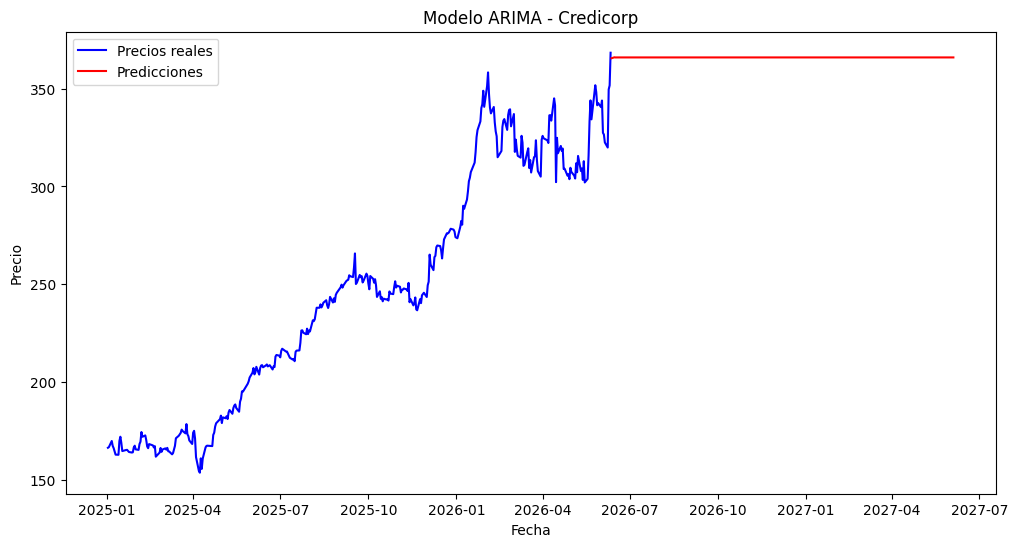

MAE: 90.3856
MSE: 10136.1637
RMSE: 100.6785


In [31]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

true_prices = stock['Close'][-256:]

mae = mean_absolute_error(true_prices, forecast)
mse = mean_squared_error(true_prices, forecast)
rmse = np.sqrt(mse)
future_dates = pd.date_range(
    start=stock.index[-1] + pd.Timedelta(days=1),
    periods=256,
    freq='B'  # días bursátiles
)

forecast = pd.Series(
    forecast.values,
    index=future_dates
)
# visualizar resultados
plt.figure(figsize=(12, 6))
plt.plot(stock['Close'], label='Precios reales', color='blue')
plt.plot(forecast, label='Predicciones', color='red')
plt.title('Modelo ARIMA - Credicorp')
plt.xlabel('Fecha')
plt.ylabel('Precio')
plt.legend()

plt.show()

print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")

In [10]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.stats.diagnostic as sms
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor


# 1. Cargar la base de datos (generada en el paso anterior)
df = pd.read_csv("base_datos_econometria.csv", index_col=0)

# Definir Variable Dependiente (Y) e Independientes (X)
y = df['R_Credicorp']
X = df[['R_Peru_Mercado', 'Precio_cobre', 'ETF_XLF']]

# ESENCIAL EN ECONOMETRÍA: Añadir la constante (Beta_0 o Intercepto)
X = sm.add_constant(X)

# 2. Ajustar el modelo de Regresión Múltiple (MCO / OLS)
modelo = sm.OLS(y, X).fit()

# Guardar los residuos (los necesitaremos para las pruebas de diagnóstico)
residuos = modelo.resid


# ==============================================================================
# IMPRESIÓN DE RESULTADOS
# ==============================================================================

print("======= 1. COEFICIENTES Y 2. NIVEL DE SIGNIFICANCIA =======")
print(modelo.summary())
print("\n" + "="*60 + "\n")

print("======= 3. PRUEBA DE NORMALIDAD (Jarque-Bera) =======")
jb_estadistico, p_valor = stats.jarque_bera(residuos)
print(f"Estadístico Jarque-Bera: {jb_estadistico:.4f}")
print(f"p-valor: {p_valor:.4f}")
if p_valor > 0.05:
    print("Resultado: No se rechaza H0. Los residuos se distribuyen NORMALMENTE.")
else:
    print("Resultado: Se rechaza H0. Los residuos NO se distribuyen normalmente.")
print("\n" + "="*60 + "\n")

print("======= 4. AUTOCORRELACIÓN =======")
# Durbin-Watson (ya viene en el summary, pero lo analizamos aquí)
dw = sm.stats.stattools.durbin_watson(residuos)
print(f"Estadístico Durbin-Watson: {dw:.4f}")
if 1.5 <= dw <= 2.5:
    print("Resultado (DW): No hay indicios graves de autocorrelación de primer orden.")
else:
    print("Resultado (DW): Alerta. Posible presencia de autocorrelación.")

# Prueba más robusta: Breusch-Godfrey (para autocorrelación de orden superior, ej. 2 rezagos)
bg_test = sms.acorr_breusch_godfrey(modelo, nlags=2)
bg_pvalue = bg_test[1]
print(f"p-valor (Breusch-Godfrey): {bg_pvalue:.4f}")
if bg_pvalue > 0.05:
    print("Resultado (BG): No hay autocorrelación en los residuos.")
else:
    print("Resultado (BG): Se rechaza H0. Existe AUTOCORRELACIÓN.")
print("\n" + "="*60 + "\n")

print("======= 5. HETEROCEDASTICIDAD (White) =======")
bp_test = sms.het_white(residuos, X)

bp_pvalue = bp_test[1]
print(f"p-valor (White): {bp_pvalue:.4f}")
if bp_pvalue > 0.05:
    print("Resultado: No se rechaza H0. Los residuos son HOMOCEDÁSTICOS (Varianza constante).")
else:
    print("Resultado: Se rechaza H0. Los residuos sufren de HETEROCEDASTICIDAD.")



======= 1. COEFICIENTES Y 2. NIVEL DE SIGNIFICANCIA =======
                            OLS Regression Results                            
Dep. Variable:            R_Credicorp   R-squared:                       0.682
Model:                            OLS   Adj. R-squared:                  0.669
Method:                 Least Squares   F-statistic:                     51.53
Date:                Sat, 13 Jun 2026   Prob (F-statistic):           6.75e-18
Time:                        00:36:54   Log-Likelihood:                 110.99
No. Observations:                  76   AIC:                            -214.0
Df Residuals:                      72   BIC:                            -204.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------